# VAL-04: 군집 시계열 안정성 — 자치구별 군집 이동 추적

**선행 조건**: `val_02_kmeans.ipynb` 실행 완료  
(`data/df_feat_clean.csv`, `data/cluster_assignments.csv`)

**목적**:
- 6년(2019~2024) 동안 군집이 이동한 자치구 파악
- 군집 이동의 피처 변화와의 연관성 분석
- 2024년 자치구별 Silhouette + 자기상관 분석



In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns
import warnings, platform
warnings.filterwarnings('ignore')

if platform.system() == 'Darwin':
    plt.rcParams['font.family'] = 'AppleGothic'
else:
    font_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
    try:
        fe = fm.FontEntry(fname=font_path, name='NanumGothic')
        fm.fontManager.ttflist.insert(0, fe)
        plt.rcParams['font.family'] = 'NanumGothic'
    except:
        pass
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 120
print('로딩 완료')

로딩 완료


---
## 1. 저장된 결과 로딩

In [12]:
import os
assert os.path.exists('data/df_feat_clean.csv'),       '❌ val_01_data.ipynb 먼저 실행'
assert os.path.exists('data/cluster_assignments.csv'), '❌ val_02_kmeans.ipynb 먼저 실행'

FEATURE_COLS = [
    'total_resident_population', 'total_households', 'gas_supply_ratio',
    'home_ratio', 'public_ratio', 'service_ratio', 'industry_ratio'
]

df_feat    = pd.read_csv('data/df_feat_clean.csv',       encoding='utf-8-sig')
cluster_df = pd.read_csv('data/cluster_assignments.csv', encoding='utf-8-sig')
YEARS      = sorted(df_feat.year.unique().tolist())
K_TARGET   = int(cluster_df['cluster'].nunique())

df = df_feat.merge(cluster_df, on=['year', 'district'], how='left')

print(f'df shape: {df.shape}')
print(f'연도: {YEARS}')
print(f'자치구 수: {df.district.nunique()}')
print(f'K_TARGET: {K_TARGET}')
print(f'cluster 유효값: {df.cluster.notna().sum()}/{len(df)}')
print(f'cluster 고유값: {sorted(df.cluster.dropna().astype(int).unique())}')

df shape: (150, 10)
연도: [2019, 2020, 2021, 2022, 2023, 2024]
자치구 수: 25
K_TARGET: 6
cluster 유효값: 150/150
cluster 고유값: [0, 1, 2, 3, 4, 5]


---
## 2. 전체 자치구 군집 이동 분석

In [13]:
cluster_pivot = df.pivot_table(
    index='district', columns='year', values='cluster', aggfunc='first'
)

n_unique = cluster_pivot.nunique(axis=1, dropna=False)
stable   = cluster_pivot[n_unique == 1]
unstable = cluster_pivot[n_unique > 1]

print(f'6년 내내 동일 군집: {len(stable)}개 자치구 ({len(stable)/df.district.nunique()*100:.0f}%)')
print(f'군집 이동 발생:      {len(unstable)}개 자치구')

if len(unstable) > 0:
    print()
    print('=== 군집 이동 자치구 상세 ===')
    print(unstable.astype('Int64').to_string())
else:
    print()
    print(f'→ K={K_TARGET} 기준 모든 자치구가 6년 내내 동일 군집에 배정됨')

6년 내내 동일 군집: 25개 자치구 (100%)
군집 이동 발생:      0개 자치구

→ K=6 기준 모든 자치구가 6년 내내 동일 군집에 배정됨


---
## 3. 군집 타임라인 히트맵

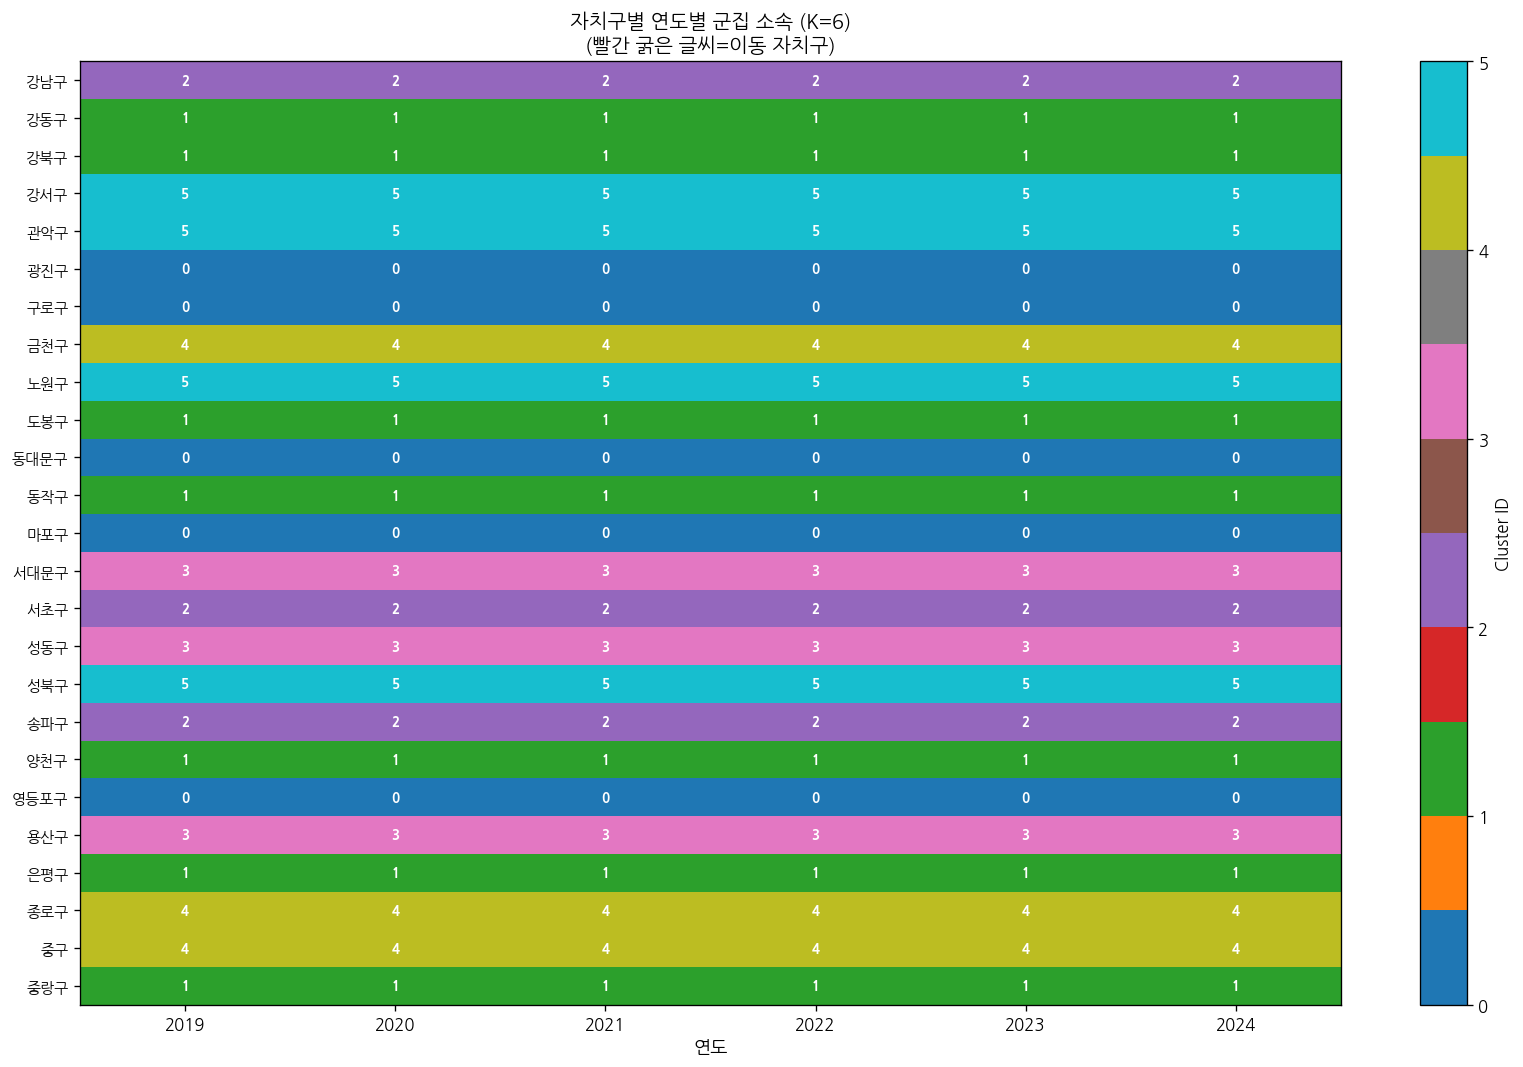

군집 ID별 2024년 소속 자치구:
  C0: 광진구, 구로구, 동대문구, 마포구, 영등포구
  C1: 강동구, 강북구, 도봉구, 동작구, 양천구, 은평구, 중랑구
  C2: 강남구, 서초구, 송파구
  C3: 서대문구, 성동구, 용산구
  C4: 금천구, 종로구, 중구
  C5: 강서구, 관악구, 노원구, 성북구


In [14]:
cp_vals = cluster_pivot.values.astype(float)

fig, ax = plt.subplots(figsize=(14, 9))
im = ax.imshow(cp_vals, aspect='auto', cmap='tab10', vmin=0, vmax=K_TARGET - 1)

ax.set_xticks(range(len(YEARS)))
ax.set_xticklabels(YEARS)
ax.set_yticks(range(len(cluster_pivot)))
ax.set_yticklabels(cluster_pivot.index, fontsize=9)
ax.set_xlabel('연도', fontsize=11)
ax.set_title(f'자치구별 연도별 군집 소속 (K={K_TARGET})\n(빨간 굵은 글씨=이동 자치구)', fontsize=12)
plt.colorbar(im, ax=ax, label='Cluster ID')

tick_labels = ax.get_yticklabels()
for i, dist in enumerate(cluster_pivot.index):
    if dist in unstable.index:
        tick_labels[i].set_color('crimson')
        tick_labels[i].set_fontweight('bold')

for yi, year in enumerate(YEARS):
    for di, dist in enumerate(cluster_pivot.index):
        val = cluster_pivot.loc[dist, year]
        if not pd.isna(val):
            ax.text(yi, di, str(int(val)), ha='center', va='center',
                    fontsize=8, color='white', fontweight='bold')

plt.tight_layout()
plt.show()

print(f'군집 ID별 2024년 소속 자치구:')
for cid in sorted(df[df.year == 2024].cluster.astype(int).unique()):
    dists = sorted(df[(df.year == 2024) & (df.cluster == cid)]['district'].tolist())
    print(f'  C{cid}: {", ".join(dists)}')

---
## 4. 경계 자치구 피처 변화 분석

군집 이동이 있든 없든, 피처 자체가 크게 변한 자치구는 군집 경계에 있을 수 있다.  
Silhouette 점수가 낮은 자치구를 추가로 확인한다.

In [15]:
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_samples

scaler = StandardScaler()
X_all = scaler.fit_transform(df[FEATURE_COLS])
labels_all = df['cluster'].astype(int).values

# 2024년만
mask_2024 = (df.year == 2024).values
X_2024      = X_all[mask_2024]
labels_2024 = labels_all[mask_2024]
dist_2024   = df[df.year == 2024]['district'].values

sil_vals = silhouette_samples(X_2024, labels_2024)
sil_df = pd.DataFrame({
    'district': dist_2024,
    'cluster':  labels_2024,
    'silhouette': sil_vals
}).sort_values('silhouette')

print('2024년 Silhouette 하위 10개 (군집 경계 자치구):')
print(sil_df.head(10).to_string(index=False))
print()


2024년 Silhouette 하위 10개 (군집 경계 자치구):
district  cluster  silhouette
     서초구        2   -0.043900
     성북구        5   -0.036716
     강서구        5    0.004329
    동대문구        0    0.034317
     노원구        5    0.060650
    서대문구        3    0.085668
     송파구        2    0.120546
     성동구        3    0.140064
     강동구        1    0.155561
     금천구        4    0.178979



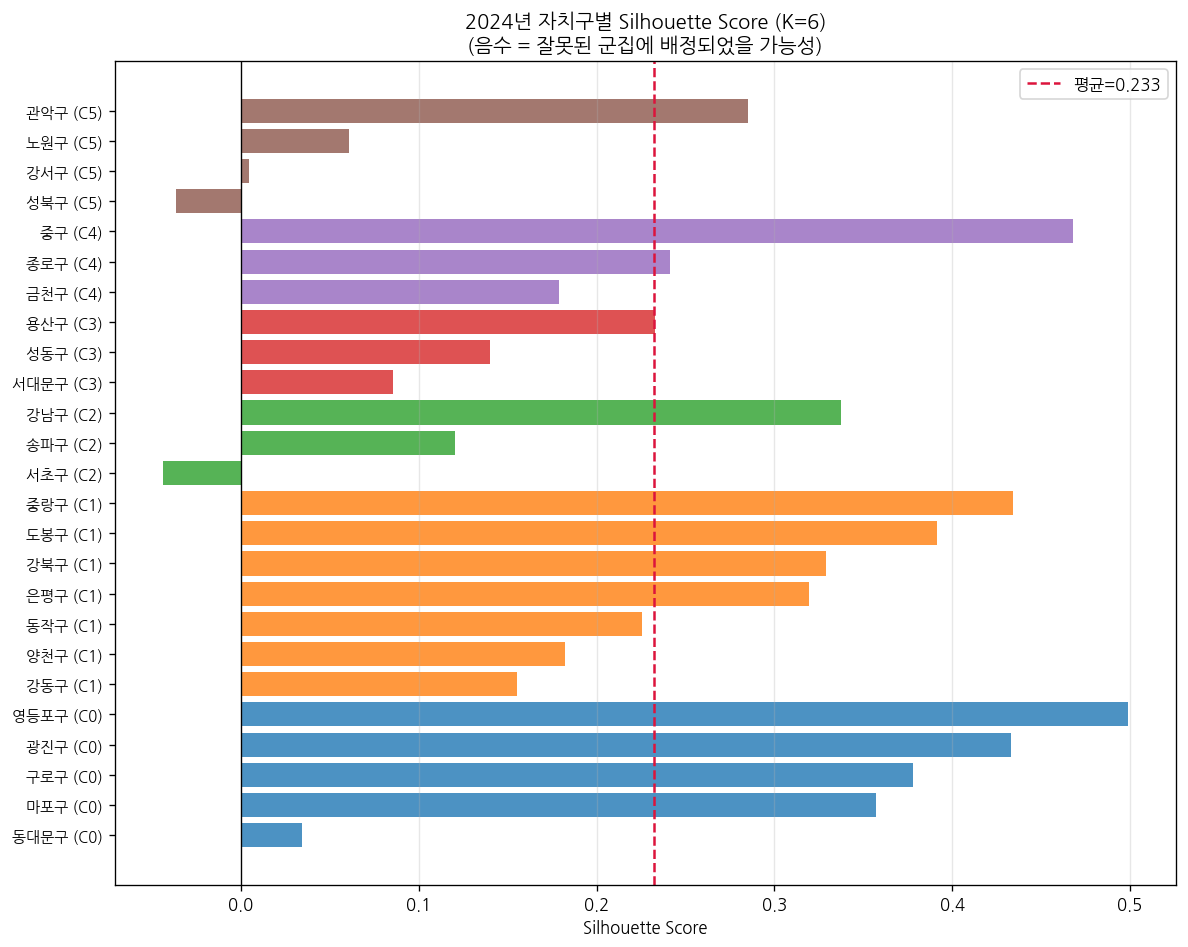

In [16]:
sil_sorted = sil_df.sort_values(['cluster', 'silhouette'])
PALETTE = sns.color_palette('tab10', K_TARGET)

fig, ax = plt.subplots(figsize=(10, 8))
colors = [PALETTE[int(c) % K_TARGET] for c in sil_sorted.cluster]
ax.barh(range(len(sil_sorted)), sil_sorted.silhouette, color=colors, alpha=0.8)
ax.axvline(0, color='black', linewidth=0.8)
overall = sil_sorted.silhouette.mean()
ax.axvline(overall, color='crimson', linestyle='--', linewidth=1.5, label=f'평균={overall:.3f}')
ax.set_yticks(range(len(sil_sorted)))
ax.set_yticklabels(
    [f"{r['district']} (C{r['cluster']})" for _, r in sil_sorted.iterrows()],
    fontsize=9
)
ax.set_xlabel('Silhouette Score')
ax.set_title(f'2024년 자치구별 Silhouette Score (K={K_TARGET})\n(음수 = 잘못된 군집에 배정되었을 가능성)', fontsize=12)
ax.legend(); ax.grid(alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

---
## 5. 자기상관 분석 (150개 관측치 설계 검증)

150개 관측치가 독립적인지, 아니면 연도 간 자기상관이 높아서  
실질적인 독립 정보량이 더 적은지 확인한다.

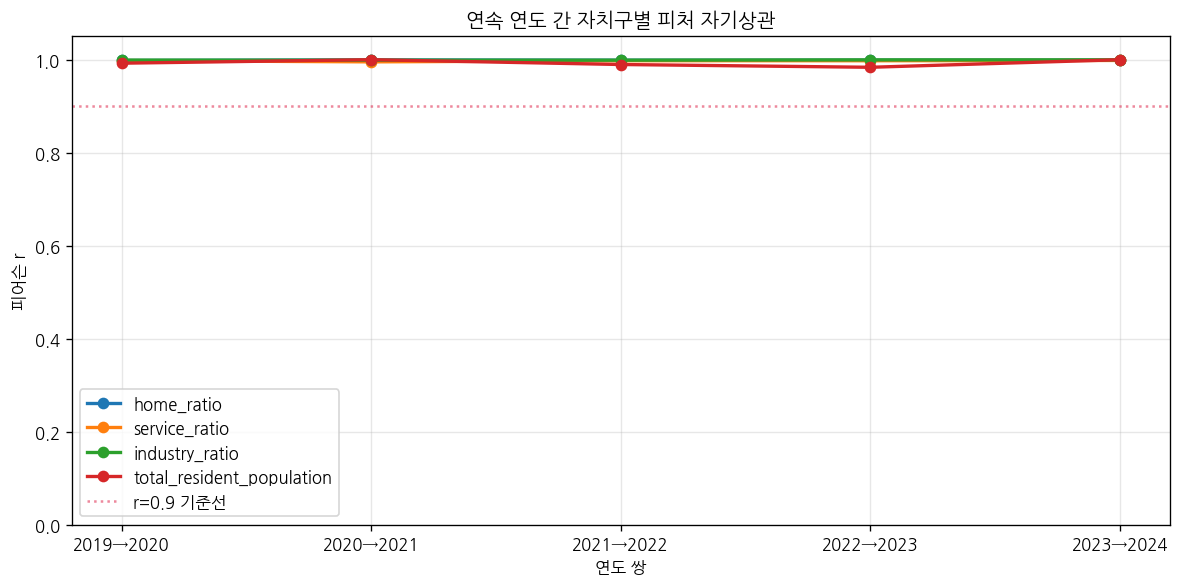

피처별 평균 자기상관:
feature
industry_ratio               0.9992
home_ratio                   0.9989
service_ratio                0.9975
total_resident_population    0.9931

→ ⚠️ 평균 자기상관 0.9972 — 연도 간 관측치가 거의 독립적이지 않음
   150개 관측치의 실질 독립 정보량이 25개 자치구 수준에 가까울 수 있음
   → 시계열 특화 군집화(DTW, LDA) 또는 패널 데이터 모델 검토 권장


In [17]:
key_features = ['home_ratio', 'service_ratio', 'industry_ratio', 'total_resident_population']
autocorr_results = []

for feat in key_features:
    year_vals = {}
    for yr in YEARS:
        # df에서 해당 연도만 슬라이싱 (df 자체를 수정하지 않음)
        sub = df[df.year == yr][['district', feat]].set_index('district')[feat]
        year_vals[yr] = sub

    for i in range(len(YEARS) - 1):
        y1, y2 = YEARS[i], YEARS[i+1]
        merged = pd.concat([year_vals[y1], year_vals[y2]], axis=1).dropna()
        merged.columns = [y1, y2]
        r = merged.corr().iloc[0, 1]
        autocorr_results.append({'feature': feat, 'year_pair': f'{y1}→{y2}', 'r': r})

ac_df = pd.DataFrame(autocorr_results)

fig, ax = plt.subplots(figsize=(10, 5))
for feat in key_features:
    sub = ac_df[ac_df.feature == feat]
    ax.plot(sub.year_pair, sub.r, 'o-', label=feat, linewidth=2)
ax.axhline(0.9, color='crimson', linestyle=':', alpha=0.5, label='r=0.9 기준선')
ax.set_ylim(0, 1.05)
ax.set_xlabel('연도 쌍'); ax.set_ylabel('피어슨 r')
ax.set_title('연속 연도 간 자치구별 피처 자기상관')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print('피처별 평균 자기상관:')
means = ac_df.groupby('feature')['r'].mean().sort_values(ascending=False)
print(means.round(4).to_string())
print()
avg_all = means.mean()
if avg_all >= 0.9:
    print(f'→ ⚠️ 평균 자기상관 {avg_all:.4f} — 연도 간 관측치가 거의 독립적이지 않음')
    print('   150개 관측치의 실질 독립 정보량이 25개 자치구 수준에 가까울 수 있음')
    print('   → 시계열 특화 군집화(DTW, LDA) 또는 패널 데이터 모델 검토 권장')
elif avg_all >= 0.7:
    print(f'→ ⚠️ 평균 자기상관 {avg_all:.4f} — 어느 정도의 시간적 종속성 존재')
else:
    print(f'→ ✅ 평균 자기상관 {avg_all:.4f} — 연도 간 변화가 충분히 독립적')

---
## 6. 검증 요약

In [ ]:
print('=' * 60)
print(f'  VAL-04 군집 시계열 검증 요약 (K={K_TARGET})')
print('=' * 60)
print()
print(f'[1] 6년 내내 동일 군집 자치구: {len(stable)}/{df.district.nunique()}')
print(f'    군집 이동 자치구: {len(unstable)}개')
if len(unstable) > 0:
    print(f'    → {list(unstable.index)}')

print()
print(f'[2] 2024년 Silhouette 평균: {overall:.4f}')
below_zero = sil_df[sil_df.silhouette < 0]
if len(below_zero) > 0:
    print(f'    Silhouette < 0 자치구 ({len(below_zero)}개): {below_zero.district.tolist()}')

print()
print(f'[3] 피처 자기상관 평균: {avg_all:.4f}')
print()
print('--- 구조적 한계 ---')
print('• K-means 레이블은 실행마다 달라질 수 있음 (군집 구조는 ARI val_03으로 검증)')
print('• 높은 자기상관 → 150개 관측치의 실질 독립성 낮음')
print('• 공간적 인접성 미반영')
print()
print('--- 발전 방향 ---')
print('• Spatially Constrained Clustering')
print('• Dynamic Time Warping 기반 시계열 군집화')

  VAL-04 군집 시계열 검증 요약 (K=6)

[1] 6년 내내 동일 군집 자치구: 25/25
    군집 이동 자치구: 0개

[2] 강동구 군집 이동 감지: 없음 (현재 레이블 기준)

[3] 2024년 Silhouette 평균: 0.2325
    Silhouette < 0 자치구 (2개): ['서초구', '성북구']

[4] 피처 자기상관 평균: 0.9972

--- 구조적 한계 ---
• K-means 레이블은 실행마다 달라질 수 있음 (군집 구조는 ARI val_03으로 검증)
• 높은 자기상관 → 150개 관측치의 실질 독립성 낮음
• 공간적 인접성 미반영

--- 발전 방향 ---
• GraphRAG: 자치구를 노드, 군집/인접을 엣지로 표현
• Spatially Constrained Clustering
• Dynamic Time Warping 기반 시계열 군집화
